In [1]:
library(plyr)
library(AUCell)
library(openxlsx)
library(ggforce)
library(tidyr)
library(ggplot2)

Warning message:
“le package ‘plyr’ a été compilé avec la version R 4.4.3”
Warning message:
“le package ‘AUCell’ a été compilé avec la version R 4.4.2”
Le chargement a nécessité le package : ggplot2

Warning message:
“le package ‘ggplot2’ a été compilé avec la version R 4.4.3”


In [2]:
load(file="/home/adufour/work/rds_storage/epilepsie/cells_AUC_epilepsie.RData")

In [4]:
load("/work/project/fragencode/workspace/umr_1141/results/epilepsie/spatial/seurat_obj/whole_clustering_subclustering_Seurat_objects.RData")

In [3]:
auc_DF <- as.data.frame(t(getAUC(cells_AUC)))

In [5]:
auc_DF <- auc_DF[,c("GOBP_REGULATION_OF_NEUROTRANSMITTER_TRANSPORT", "GOBP_ASTROCYTE_DEVELOPMENT")]

In [6]:
seurat_object_whole_clustering@meta.data$cat <- "none"

Le chargement a nécessité le package : SeuratObject

Warning message:
“le package ‘SeuratObject’ a été compilé avec la version R 4.4.3”
Le chargement a nécessité le package : sp

Warning message:
“le package ‘sp’ a été compilé avec la version R 4.4.2”

Attachement du package : ‘SeuratObject’


Les objets suivants sont masqués depuis ‘package:base’:

    intersect, t




In [7]:
seurat_object_whole_clustering@meta.data[rownames(auc_DF[auc_DF$GOBP_REGULATION_OF_NEUROTRANSMITTER_TRANSPORT < 0.18 & auc_DF$GOBP_ASTROCYTE_DEVELOPMENT > 0.15,]),]$cat <- "astro_dev"
seurat_object_whole_clustering@meta.data[rownames(auc_DF[auc_DF$GOBP_REGULATION_OF_NEUROTRANSMITTER_TRANSPORT > 0.18 & auc_DF$GOBP_ASTROCYTE_DEVELOPMENT < 0.15,]),]$cat <- "long_term"
seurat_object_whole_clustering@meta.data[rownames(auc_DF[auc_DF$GOBP_REGULATION_OF_NEUROTRANSMITTER_TRANSPORT > 0.18 & auc_DF$GOBP_ASTROCYTE_DEVELOPMENT > 0.15,]),]$cat <- "both"

In [8]:
seurat_object_whole_clustering@meta.data$cluster_id <- paste0(seurat_object_whole_clustering@meta.data$seurat_custom_clusters, "_", seurat_object_whole_clustering@meta.data$time, "_", seurat_object_whole_clustering@meta.data$condition, "_", seurat_object_whole_clustering@meta.data$cat)

In [9]:
# Liste des combinaisons uniques
unique_groups <- unique(seurat_object_whole_clustering@meta.data$cluster_id)

# Crée une liste avec les rownames pour chaque combinaison unique
rownames_by_group <- lapply(unique_groups, function(g) {
  rownames(seurat_object_whole_clustering@meta.data[seurat_object_whole_clustering@meta.data$cluster_id == g, ])
})
names(rownames_by_group) <- unique_groups

In [10]:
# Définir l'ordre souhaité
clusters_order <- c("0.0", "0.1", "0.2", "0.3", "3.0", "3.1", "3.2", "3.3", "1", "2", "4")
conditions <- c("SE", "CTRL")
time_points <- c("5", "10", "20", "40")
go_terms <- c('none', 'both', 'astro_dev', 'long_term')

# Initialiser les vecteurs
clusters_vec <- c()
condition_vec <- c()
time_vec <- c()
go_vec <- c()
count_vec <- c()

for (cl in clusters_order) {
  for (cond in conditions) {
    for (tm in time_points) {
      for (go in go_terms) {
          group_name <- paste(cl, tm, cond, go, sep = "_")
          clusters_vec <- c(clusters_vec, cl)
          condition_vec <- c(condition_vec, cond)
          time_vec <- c(time_vec, tm)
          go_vec <- c(go_vec, go)
          count_vec <- c(count_vec, length(rownames_by_group[[group_name]]))
      }
    }
  }
}

In [11]:
df <- data.frame(Condition = condition_vec,
    Time = time_vec,
    Cluster = clusters_vec,
    GO = go_vec,
    Count = count_vec)

In [21]:
data <- df %>%
  gather_set_data(1:4) %>%
  dplyr::mutate(
    x = factor(x, levels = c('Condition', 'Time', 'GO', 'Cluster')),
    y = factor(y, levels = c('CTRL', 'SE', '5', '10', '20', '40', 'astro_dev', 'both', 'long_term', 'none', '0.0', '0.1', '0.2', '0.3', '1', '2', '3.0', '3.1', '3.2', '3.3', '4'))
  )

In [22]:
data_labels <- tibble(
    group = c(
      rep('P3', 9),
      rep('P5', 9),
      rep('P15', 9)
    )
 ) %>%
  mutate(
    hjust = ifelse(group == 'P3', 1, 0),
    nudge_x = ifelse(group == 'P3', -0.1, 0.1)
  )

In [23]:
color_assignments <- setNames(
  c("#fcbba1", "#737373", "#FEEDDE", "#FBDE85", "#FD8D3C", "#D94701", "#238b45", "#74c476", "#bae4b3", "#edf8e9", "#fdf498", "#807dba", "#4a1486", "#ac8fff", "#cccccc", "#f768a1", "#bae1ff", "#ef3b2c", "#c56cf0", "#17c0eb", "#4b4b4b"),
  c("SE", "CTRL", "5", "10", "20", "40", "0.0", "0.1", "0.2", "0.3", "3.0", "3.1", "3.2", "3.3", "1", "2", "4", 'astro_dev', 'both', 'long_term', 'none')
)

In [24]:
p1 <- ggplot(data, aes(x, id = id, split = y, value = Count)) +
  geom_parallel_sets(aes(fill = Condition), alpha = 0.75, axis.width = 0.15) +
  #geom_parallel_sets(aes(fill = P5), alpha = 0.75, axis.width = 0.15) +
  geom_parallel_sets_axes(aes(fill = y), color = 'black', axis.width = 0.1) +
  geom_text(
    aes(y = Count, split = y), size = 12, stat = 'parallel_sets_axes', fontface = 'bold'#,
    #hjust = data_labels$hjust, nudge_x = data_labels$nudge_x
  ) +
  #scale_x_discrete(labels = c('P3','P5', 'P15')) +
  scale_fill_manual(values = color_assignments) +
  theme_bw() +
  theme(
    legend.position = 'none',
    axis.title = element_blank(),
    axis.text.x = element_text(face = 'bold', colour = 'black', size = 24),
    axis.text.y = element_blank(),
    axis.ticks = element_blank(),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    panel.border = element_blank()
  )

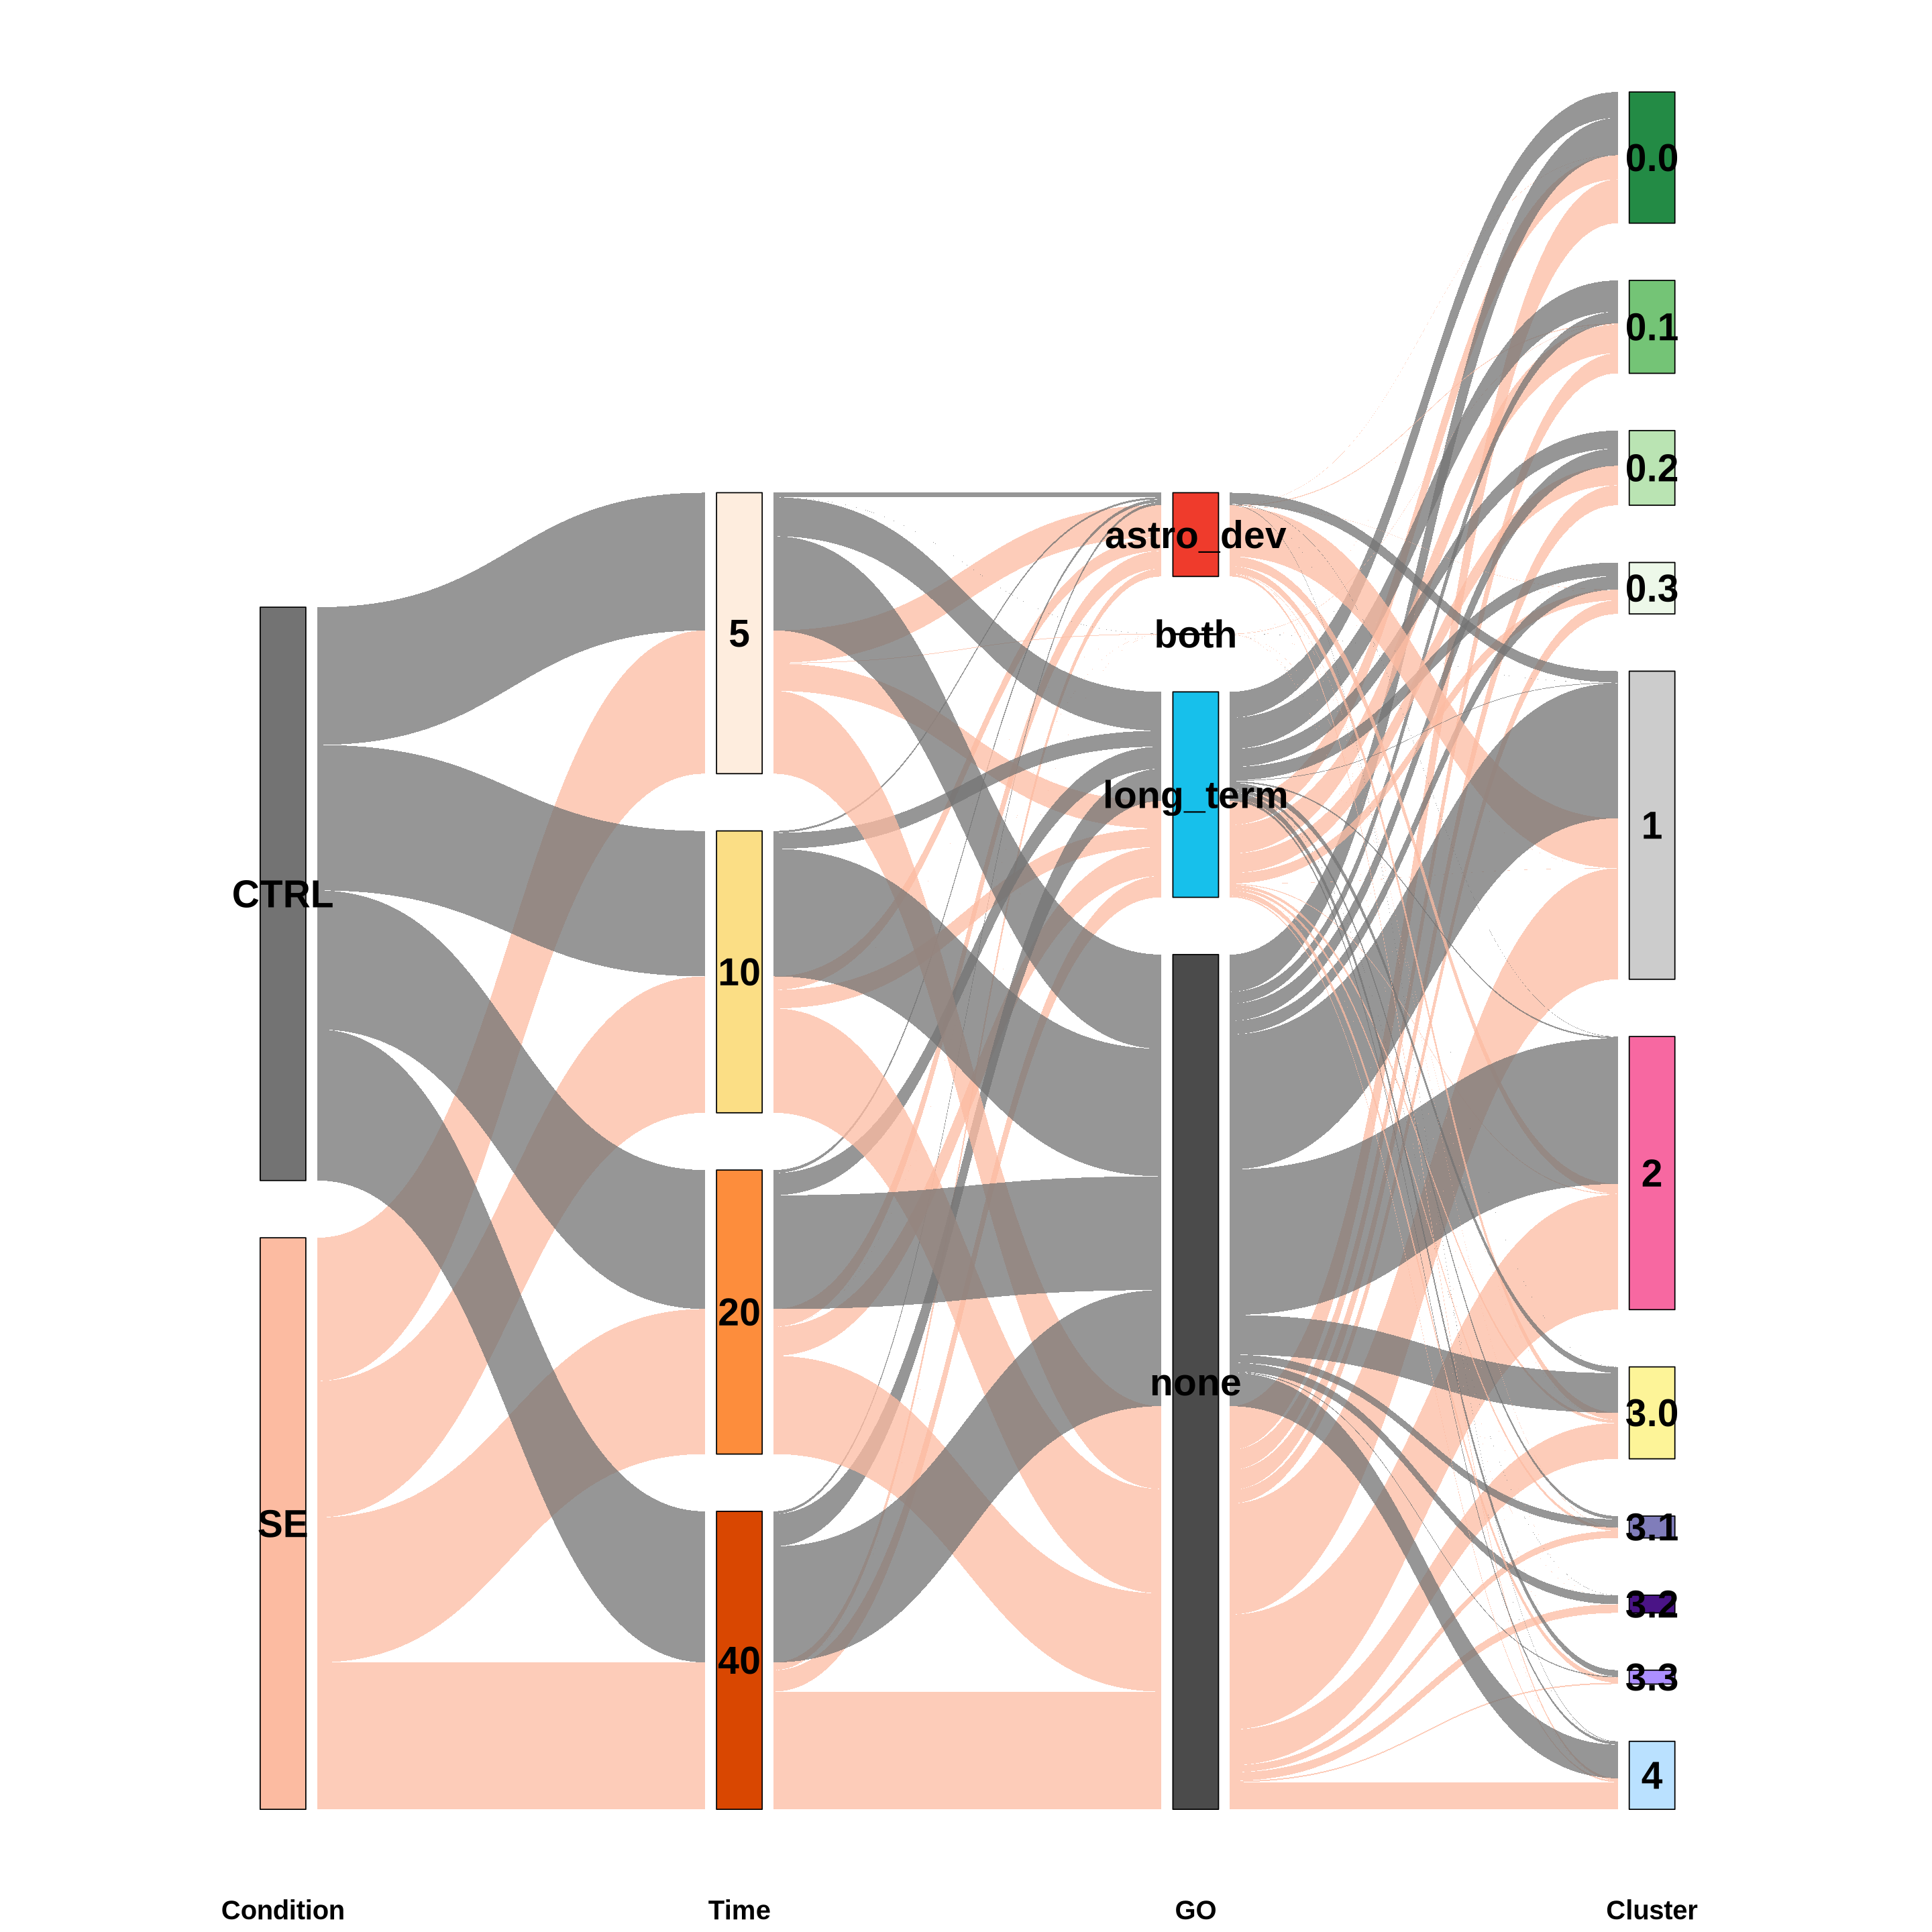

In [25]:
options(repr.plot.width = 24, repr.plot.height = 24, repr.plot.pointsize = 24)
p1

In [26]:
ggsave(
  '/home/adufour/work/plots/epilepsie/alluvial_with_none.svg',
  p1,
  height = 18,
  width = 20
)